In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import randint, uniform
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    f1_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.linear_model import LogisticRegression, SGDClassifier, RidgeClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, BaggingClassifier, ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier

In [2]:
#Import dataset
df_0 = pd.read_csv('C:\\Users\\miche\\Documents\\MSDS696\\FL_BrwrdCnty_Rcdvsm.csv')

In [3]:
#Look at the information the dataset 
print(df_0.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 52 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       11001 non-null  float64
 1   name                     18316 non-null  object 
 2   first                    18316 non-null  object 
 3   last                     18316 non-null  object 
 4   compas_screening_date    18316 non-null  object 
 5   sex                      18316 non-null  object 
 6   dob                      18316 non-null  object 
 7   age                      18316 non-null  int64  
 8   age_cat                  18316 non-null  object 
 9   race                     18316 non-null  object 
 10  juv_fel_count            18316 non-null  int64  
 11  decile_score             18316 non-null  int64  
 12  juv_misd_count           18316 non-null  int64  
 13  juv_other_count          18316 non-null  int64  
 14  priors_count          

In [4]:
#Print entries of target value is_recid
print(df_0['is_recid'].unique())

[ 0 -1  1]


In [5]:
#Print first values for EDA
columns = df_0.columns.tolist()
first_row = df_0.iloc[0].tolist()
print("\nFirst row values:")
for col, val in zip(columns, first_row):
    print(f"  {col}: {val}")


First row values:
  id: 1.0
  name: miguel hernandez
  first: miguel
  last: hernandez
  compas_screening_date: 14/08/2013
  sex: Male
  dob: 18/04/1947
  age: 69
  age_cat: Greater than 45
  race: Other
  juv_fel_count: 0
  decile_score: 1
  juv_misd_count: 0
  juv_other_count: 0
  priors_count: 0
  days_b_screening_arrest: -1.0
  c_jail_in: 13/08/2013 6:03
  c_jail_out: 14/08/2013 5:41
  c_case_number: 13011352CF10A
  c_offense_date: 13/08/2013
  c_arrest_date: nan
  c_days_from_compas: 1.0
  c_charge_degree: (F3)
  c_charge_desc: Aggravated Assault w/Firearm
  is_recid: 0
  r_case_number: nan
  r_charge_degree: nan
  r_days_from_arrest: nan
  r_offense_date: nan
  r_charge_desc: nan
  r_jail_in: nan
  r_jail_out: nan
  violent_recid: nan
  is_violent_recid: 0
  vr_case_number: nan
  vr_charge_degree: nan
  vr_offense_date: nan
  vr_charge_desc: nan
  type_of_assessment: Risk of Recidivism
  decile_score.1: 1
  score_text: Low
  screening_date: 14/08/2013
  v_type_of_assessment: Ris

In [6]:
#Check if there are any null values
print(df_0.isnull().sum())

id                          7315
name                           0
first                          0
last                           0
compas_screening_date          0
sex                            0
dob                            0
age                            0
age_cat                        0
race                           0
juv_fel_count                  0
decile_score                   0
juv_misd_count                 0
juv_other_count                0
priors_count                   0
days_b_screening_arrest     1297
c_jail_in                   1297
c_jail_out                  1297
c_case_number                867
c_offense_date              3952
c_arrest_date              15231
c_days_from_compas           867
c_charge_degree              867
c_charge_desc                881
is_recid                       0
r_case_number               9899
r_charge_degree             9899
r_days_from_arrest         11957
r_offense_date              9899
r_charge_desc              10039
r_jail_in 

In [7]:
#Look at race distribution
race_counts = df_0['race'].value_counts()

#Calculate percentage distribution for graph
race_percent = df_0['race'].value_counts(normalize=True) * 100

#Combine into one table
race_distribution = pd.DataFrame({
    'Count': race_counts,
    'Percentage (%)': race_percent.round(2)})

#Print the table
print(race_distribution)

                  Count  Percentage (%)
race                                   
African-American   9791           53.46
Caucasian          6086           33.23
Hispanic           1451            7.92
Other               860            4.70
Asian                71            0.39
Native American      57            0.31


In [8]:
#Create a copy to preserve original dataset
df_1 = df_0.copy()

In [9]:
#Change some columns to have datetime, so it can be easier to look at the years/timeline during EDA
date_cols = [
    'compas_screening_date', 'dob', 'c_jail_in', 'c_jail_out',
    'c_offense_date', 'c_arrest_date', 'r_offense_date',
    'r_jail_in', 'r_jail_out', 'vr_offense_date',
    'screening_date', 'v_screening_date',
    'in_custody', 'out_custody'
]

for col in date_cols:
    df_1[col] = pd.to_datetime(df_1[col], dayfirst=True, errors='coerce')

#Calculate days in jail
df_1['days_in_jail'] = (df_1['c_jail_out'] - df_1['c_jail_in']).dt.days.abs()

In [10]:
#look at the information of the new subset of data with the changed columns to dates
print(df_1.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   id                       11001 non-null  float64       
 1   name                     18316 non-null  object        
 2   first                    18316 non-null  object        
 3   last                     18316 non-null  object        
 4   compas_screening_date    18316 non-null  datetime64[ns]
 5   sex                      18316 non-null  object        
 6   dob                      18316 non-null  datetime64[ns]
 7   age                      18316 non-null  int64         
 8   age_cat                  18316 non-null  object        
 9   race                     18316 non-null  object        
 10  juv_fel_count            18316 non-null  int64         
 11  decile_score             18316 non-null  int64         
 12  juv_misd_count           18316 n

In [11]:
#Check for null values
print(df_1.isnull().sum())

id                          7315
name                           0
first                          0
last                           0
compas_screening_date          0
sex                            0
dob                            0
age                            0
age_cat                        0
race                           0
juv_fel_count                  0
decile_score                   0
juv_misd_count                 0
juv_other_count                0
priors_count                   0
days_b_screening_arrest     1297
c_jail_in                   1297
c_jail_out                  1297
c_case_number                867
c_offense_date              3952
c_arrest_date              15231
c_days_from_compas           867
c_charge_degree              867
c_charge_desc                881
is_recid                       0
r_case_number               9899
r_charge_degree             9899
r_days_from_arrest         11957
r_offense_date              9899
r_charge_desc              10039
r_jail_in 

In [12]:
df_2 = df_1.copy()

#Do not include columns that indicate any scoring (score columns) and ID columns 
leakage_cols = [
    'name', 'dob',
    'decile_score', 'score_text',
    'v_decile_score', 'v_score_text',
    'is_violent_recid',
    'days_in_jail',
    'c_jail_out'
]

df_2 = df_2.drop(columns=[col for col in leakage_cols if col in df_2.columns])

#For model trainig, replace the -1 entries with null values and drop because it is not part of the binary classification 
df_2['is_recid'] = df_2['is_recid'].replace(-1, np.nan)
df_2 = df_2.dropna(subset=['is_recid'])

In [13]:
#Define the target which is predicting recidivism
target = 'is_recid'  
y = df_2[target]
X = df_2.drop(columns=[target])

In [14]:
#Drop the columns that have missing values for the whole column
all_missing_cols = X.columns[X.isnull().all()]
X = X.drop(columns=all_missing_cols)

In [15]:
#Drop the columns that have datetime data type to 
date_cols = X.select_dtypes(include=['datetime64[ns]']).columns
X = X.drop(columns=date_cols, errors='ignore')

#Define column types
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(include=['number']).columns

In [16]:
#Print the new table information 
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17496 entries, 0 to 18315
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       10542 non-null  float64
 1   first                    17496 non-null  object 
 2   last                     17496 non-null  object 
 3   sex                      17496 non-null  object 
 4   age                      17496 non-null  int64  
 5   age_cat                  17496 non-null  object 
 6   race                     17496 non-null  object 
 7   juv_fel_count            17496 non-null  int64  
 8   juv_misd_count           17496 non-null  int64  
 9   juv_other_count          17496 non-null  int64  
 10  priors_count             17496 non-null  int64  
 11  days_b_screening_arrest  17018 non-null  float64
 12  c_case_number            17448 non-null  object 
 13  c_days_from_compas       17448 non-null  float64
 14  c_charge_degree          17

In [17]:
#Numeric imputation
num_imputer = SimpleImputer(strategy='median')

X_num = pd.DataFrame(
    num_imputer.fit_transform(X[num_cols]),
    columns=num_cols,
    index=X.index
)

#Categorical handling
X_cat = X[cat_cols].fillna('Missing')


#Combine both column types
X = pd.concat([X_num, X_cat], axis=1)

#Drop columns with missing ratio more than 60%
missing_ratio = X.isnull().mean()
X = X.loc[:, missing_ratio < 0.6]

print("Remaining missing values:\n", X.isnull().sum().sort_values(ascending=False).head())
print("\nFinal shape:", X.shape)

Remaining missing values:
 id                    0
age                   0
type_of_assessment    0
vr_charge_desc        0
vr_charge_degree      0
dtype: int64

Final shape: (17496, 30)


In [18]:
#Check the table after imputation 
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17496 entries, 0 to 18315
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       17496 non-null  float64
 1   age                      17496 non-null  float64
 2   juv_fel_count            17496 non-null  float64
 3   juv_misd_count           17496 non-null  float64
 4   juv_other_count          17496 non-null  float64
 5   priors_count             17496 non-null  float64
 6   days_b_screening_arrest  17496 non-null  float64
 7   c_days_from_compas       17496 non-null  float64
 8   r_days_from_arrest       17496 non-null  float64
 9   decile_score.1           17496 non-null  float64
 10  priors_count.1           17496 non-null  float64
 11  start                    17496 non-null  float64
 12  end                      17496 non-null  float64
 13  event                    17496 non-null  float64
 14  first                    17

In [19]:
#Define the features that will be used in the model 
features = [
    'age', 'age_cat', 'sex', 'race',
    'priors_count',
    'juv_fel_count',
    'juv_misd_count',
    'juv_other_count',
    'c_charge_degree',
    'c_charge_desc',
    'days_b_screening_arrest',
    'c_days_from_compas',
    'start',
    'end',
    'event',
    'has_r_case',
    'has_vr_case'
]

In [20]:
# Keep only features that actually exist in X
features_to_use = [col for col in features if col in X.columns]

X = X[features_to_use].copy()

In [21]:
print("Final features used:", X.columns.tolist())
print("Shape:", X.shape)

Final features used: ['age', 'age_cat', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree', 'c_charge_desc', 'days_b_screening_arrest', 'c_days_from_compas', 'start', 'end', 'event']
Shape: (17496, 15)


In [22]:
#Look at the shape of the feature matrix 
le = LabelEncoder()
for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col].astype(str))
 
print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts()) 

Feature matrix shape: (17496, 15)
Target distribution:
 is_recid
0.0    9079
1.0    8417
Name: count, dtype: int64


In [23]:
#Package imports for modeling
import xgboost as xgb
import lightgbm as lgb
from fairlearn.metrics import (
    demographic_parity_difference, equalized_odds_difference, MetricFrame
)

In [24]:
#Create copy of dataset for feature engineering
X_fe = X.copy()

#Age buckets
if 'age' in X_fe.columns:
    X_fe['age_bucket']    = pd.cut(X_fe['age'], bins=[0,21,25,30,40,200],
                                    labels=[0,1,2,3,4]).astype(float)
    X_fe['is_young_adult'] = (X_fe['age'] < 25).astype(int)

#Juvenile history
if 'juv_fel_count' in X_fe.columns and 'juv_misd_count' in X_fe.columns:
    X_fe['total_juv_charges'] = X_fe['juv_fel_count'] + X_fe['juv_misd_count']
    X_fe['has_juv_history']   = (X_fe['total_juv_charges'] > 0).astype(int)

#Prior-offence indicator
if 'priors_count' in X_fe.columns:
    X_fe['priors_log1p']       = np.log1p(X_fe['priors_count'])
    X_fe['is_repeat_offender'] = (X_fe['priors_count'] >= 3).astype(int)
    if 'total_juv_charges' in X_fe.columns:
        X_fe['lifetime_charges'] = X_fe['priors_count'] + X_fe['total_juv_charges']

#If there is an indication person is young adult and has prior offenses
if 'priors_count' in X_fe.columns and 'is_young_adult' in X_fe.columns:
    X_fe['priors_x_young'] = X_fe['priors_count'] * X_fe['is_young_adult']

new_feats = [c for c in X_fe.columns if c not in X.columns]
print(f'Features before: {X.shape[1]}  →  after: {X_fe.shape[1]}')
print(f'New features ({len(new_feats)}):', new_feats)


Features before: 15  →  after: 23
New features (8): ['age_bucket', 'is_young_adult', 'total_juv_charges', 'has_juv_history', 'priors_log1p', 'is_repeat_offender', 'lifetime_charges', 'priors_x_young']


In [25]:
#Preserve race column for fairness metrics
race_col = 'race'
if race_col in df_2.columns:
    race_series = df_2[race_col].copy()
    print('Race distribution:')
    print(race_series.value_counts())
else:
    race_series = None
    print('Double check data set, race column not found')


Race distribution:
race
African-American    9419
Caucasian           5782
Hispanic            1355
Other                825
Asian                 64
Native American       51
Name: count, dtype: int64


In [26]:
#Split dataset for model training
X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y, test_size=0.20, random_state=42, stratify=y
)

race_test = race_series.loc[X_test.index] if race_series is not None else None

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Target balance (train):\n{y_train.value_counts(normalize=True).round(3)}')


Train: 13996 rows | Test: 3500 rows
Target balance (train):
is_recid
0.0    0.519
1.0    0.481
Name: proportion, dtype: float64


In [27]:
#Define 10 models 
classifiers = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'        : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Extra Trees'          : ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=200, random_state=42),
    'XGBoost'              : xgb.XGBClassifier(n_estimators=200, eval_metric='logloss',
                                                random_state=42, verbosity=0),
    'LightGBM'             : lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
    'K-Nearest Neighbors'  : KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Naive Bayes'          : GaussianNB(),
    'MLP Neural Network'   : MLPClassifier(hidden_layer_sizes=(128, 64),
                                            max_iter=500, random_state=42),
}

pipelines = {
    name: Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    for name, clf in classifiers.items()
}
print(f'{len(pipelines)} classifiers ready.')


10 classifiers ready.


In [28]:
#Show if the models have been trained
fitted_models = {}
predictions   = {}   

for name, pipe in pipelines.items():
    print(f'  Training {name} is ', end=' ', flush=True)
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_prob = (pipe.predict_proba(X_test)[:, 1]
              if hasattr(pipe.named_steps['clf'], 'predict_proba')
              else pipe.decision_function(X_test))
    fitted_models[name] = pipe
    predictions[name]   = (y_pred, y_prob)
    print('done')


  Training Logistic Regression is  done
  Training Decision Tree is  done
  Training Random Forest is  done
  Training Extra Trees is  done
  Training Gradient Boosting is  done
  Training XGBoost is  done
  Training LightGBM is  done
  Training K-Nearest Neighbors is  done
  Training Naive Bayes is  done
  Training MLP Neural Network is  done


In [29]:
#Look at the accuracy of the models and compare them with each other
def evaluate_model(name, y_true, y_pred, y_prob, sensitive_features=None):
    row = {'Model': name}
    row['Accuracy']    = round(accuracy_score(y_true, y_pred), 4)
    row['ROC-AUC']     = round(roc_auc_score(y_true, y_prob), 4)
    row['F1 (macro)']  = round(f1_score(y_true, y_pred, average='macro'), 4)
    row['Precision']   = round(precision_score(y_true, y_pred, zero_division=0), 4)
    row['Recall']      = round(recall_score(y_true, y_pred), 4)
    tn, fp, fn, tp     = confusion_matrix(y_true, y_pred).ravel()
    row['FPR']         = round(fp / (fp + tn), 4)
    row['FNR']         = round(fn / (fn + tp), 4)
    if sensitive_features is not None:
        row['DPD'] = round(abs(demographic_parity_difference(
                        y_true, y_pred, sensitive_features=sensitive_features)), 4)
        row['EOD'] = round(abs(equalized_odds_difference(
                        y_true, y_pred, sensitive_features=sensitive_features)), 4)
    else:
        row['DPD'] = None
        row['EOD'] = None
    return row

results = [evaluate_model(name, y_test, yp, ypr, sensitive_features=race_test)
           for name, (yp, ypr) in predictions.items()]

eval_df = (pd.DataFrame(results)
           .set_index('Model')
           .sort_values('ROC-AUC', ascending=False))

print('Baseline Model Evaluation Table')
print(eval_df.to_string())


Baseline Model Evaluation Table
                     Accuracy  ROC-AUC  F1 (macro)  Precision  Recall     FPR     FNR     DPD     EOD
Model                                                                                                
Extra Trees            0.8054   0.8901      0.8051     0.7987  0.7963  0.1861  0.2037  0.2979  0.2426
LightGBM               0.8103   0.8850      0.8101     0.7982  0.8106  0.1900  0.1894  0.2708  0.2332
XGBoost                0.8086   0.8838      0.8083     0.8021  0.7993  0.1828  0.2007  0.3214  0.4000
Random Forest          0.7840   0.8724      0.7838     0.7707  0.7844  0.2164  0.2156  0.4643  0.4091
Gradient Boosting      0.7740   0.8517      0.7740     0.7479  0.7999  0.2500  0.2001  0.3392  0.3121
MLP Neural Network     0.7557   0.8184      0.7552     0.7502  0.7381  0.2280  0.2619  0.2589  0.3115
Decision Tree          0.7423   0.8160      0.7423     0.7139  0.7749  0.2880  0.2251  0.2869  0.4000
Logistic Regression    0.7469   0.8155      0.7467

In [30]:
#Per race FPR and FNR breakdown
if race_test is not None:
    records = []
    for name, (y_pred, _) in predictions.items():
        for grp in race_test.unique():
            mask = race_test == grp
            yt, yp = y_test[mask], y_pred[mask]
            if len(yt) < 5 or len(yt.unique()) < 2:
                continue
            tn, fp, fn, tp = confusion_matrix(yt, yp).ravel()
            records.append({
                'Model': name, 'Race': grp,
                'N':    int(mask.sum()),
                'Acc':  round(accuracy_score(yt, yp), 4),
                'FPR':  round(fp / (fp + tn), 4),
                'FNR':  round(fn / (fn + tp), 4),
                'Recall': round(tp / (tp + fn), 4),
            })

    race_df = pd.DataFrame(records).set_index(['Model', 'Race'])

    print('Top 3 models by ROC-AUC, per-race breakdown:')
    top3 = eval_df.index[:3].tolist()
    print(race_df[race_df.index.get_level_values('Model').isin(top3)].to_string())
else:
    print('Race column unavailable, check data table.')


Top 3 models by ROC-AUC, per-race breakdown:
                                 N     Acc     FPR     FNR  Recall
Model       Race                                                  
Extra Trees Hispanic           277  0.8520  0.1257  0.1977  0.8023
            African-American  1867  0.7820  0.2426  0.1974  0.8026
            Caucasian         1172  0.8191  0.1513  0.2192  0.7808
            Other              161  0.8758  0.0800  0.1967  0.8033
            Asian               16  0.9375  0.0000  0.2000  0.8000
            Native American      7  1.0000  0.0000  0.0000  1.0000
XGBoost     Hispanic           277  0.8484  0.1204  0.2209  0.7791
            African-American  1867  0.7895  0.2379  0.1876  0.8124
            Caucasian         1172  0.8251  0.1362  0.2250  0.7750
            Other              161  0.8385  0.1500  0.1803  0.8197
            Asian               16  0.8125  0.0909  0.4000  0.6000
            Native American      7  0.8571  0.2500  0.0000  1.0000
LightGBM    Hispa

### 6 · Visualisations


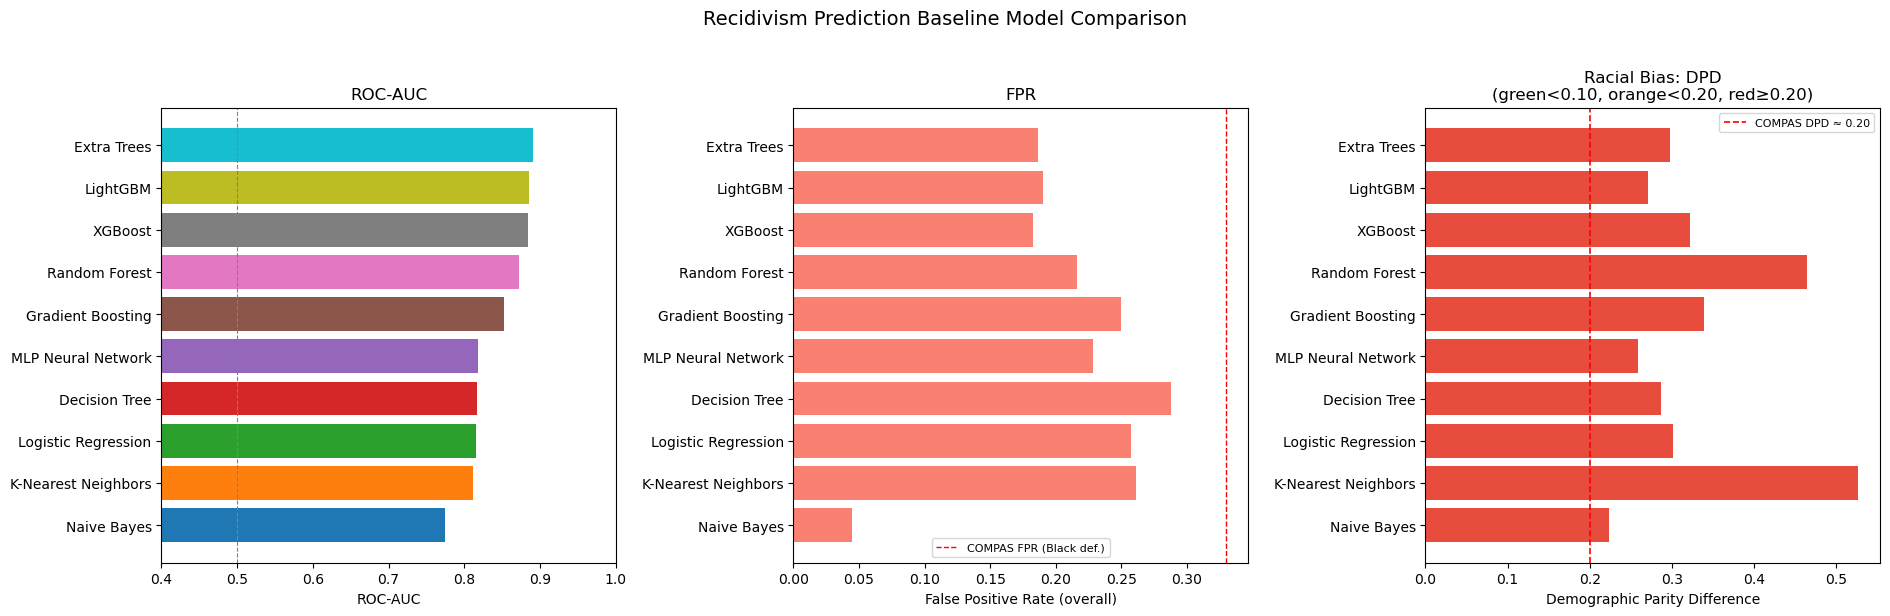

Saved: baseline_model_comparison_1.png


In [32]:
#Print graphs for the model output comparisons 
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
models_rev = eval_df.index.tolist()[::-1]
palette = sns.color_palette('tab10', len(models_rev))

#ROC-AUC bar
axes[0].barh(models_rev, eval_df.loc[models_rev, 'ROC-AUC'], color=palette)
axes[0].axvline(0.5, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('ROC-AUC'); axes[0].set_xlim(0.4, 1.0)
axes[0].set_title('ROC-AUC')

#FPR bar
axes[1].barh(models_rev, eval_df.loc[models_rev, 'FPR'], color='salmon')
axes[1].axvline(0.33, color='red', linestyle='--', linewidth=1,
                 label='COMPAS FPR (Black def.)')
axes[1].set_xlabel('False Positive Rate (overall)')
axes[1].set_title('FPR')
axes[1].legend(fontsize=8)

#DPD bias metric
if eval_df['DPD'].notna().any():
    dpd = eval_df.loc[models_rev, 'DPD'].fillna(0)
    bar_colors = ['#2ecc71' if v < 0.10 else '#f39c12' if v < 0.20 else '#e74c3c'
                  for v in dpd]
    axes[2].barh(models_rev, dpd, color=bar_colors)
    axes[2].axvline(0.20, color='red', linestyle='--', linewidth=1.2,
                     label='COMPAS DPD ≈ 0.20')
    axes[2].set_xlabel('Demographic Parity Difference')
    axes[2].set_title('Racial Bias: DPD\n(green<0.10, orange<0.20, red≥0.20)')
    axes[2].legend(fontsize=8)
else:
    axes[2].text(0.5, 0.5, 'Race data is unavailable',
                  ha='center', va='center', transform=axes[2].transAxes)

plt.suptitle('Recidivism Prediction Baseline Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('baseline_model_comparison_1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: baseline_model_comparison_1.png')


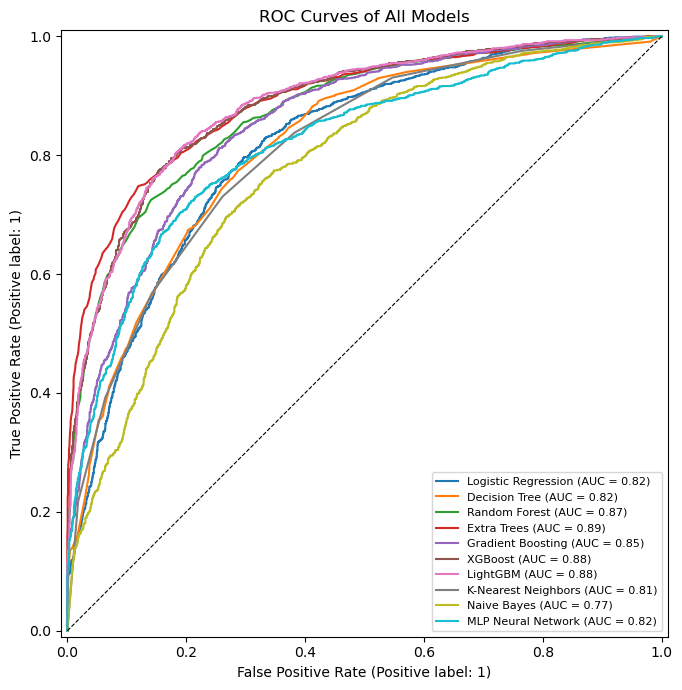

In [33]:
#ROC Curves for all models
fig, ax = plt.subplots(figsize=(9, 7))
for name, (_, y_prob) in predictions.items():
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=ax)
ax.plot([0,1],[0,1],'k--',linewidth=0.8)
ax.set_title('ROC Curves of All Models')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('roc_curves_1.png', dpi=150, bbox_inches='tight')
plt.show()
